In [1]:
import os
import sys
import pandas as pd
import numpy as np
import glob
import time
import gget
import scipy
from scipy.sparse import csr_matrix
import anndata as an
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import random
from importlib import reload
import warnings
import ot
from scipy.spatial.distance import pdist, squareform
from matplotlib.colors import ListedColormap
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import MinMaxScaler

"""WARNING: no warnings"""
warnings.filterwarnings("ignore")

source_path = os.path.abspath("../utilities/calculations/")
sys.path.append(source_path)
import centrality as central

## Load Population Data

In [2]:
%%time 
# 1MB resolution
resolution = 1000000

fpath = f"/nfs/turbo/umms-indikar/shared/projects/poreC/pipeline_outputs/higher_order/anndata/population_mESC_{resolution}_features.h5ad"

adata = sc.read_h5ad(fpath)

sc.logging.print_memory_usage()

adata

Memory usage: current 2.98 GB, difference +2.98 GB
CPU times: user 12.4 s, sys: 2.63 s, total: 15 s
Wall time: 20.9 s


AnnData object with n_obs × n_vars = 2579 × 2756467
    obs: 'bin_index', 'bin_start', 'bin_end', 'bin', 'chrom', 'chrom_bin', 'degree', 'genes', 'n_genes', 'ATACSeq_1', 'ATACSeq_2', 'ATACSeq_3', 'CTCF', 'H3K27ac', 'H3K27me3', 'RNA_1', 'RNA_2', 'RNA_3', 'RNA_4', 'RNA_5', 'RNA_6', 'PolII'
    var: 'read_index', 'basename', 'mean_mapq', 'median_mapq', 'n_chromosomes', 'order', 'n_bins', 'read_length_bp', 'genes', 'n_genes'
    uns: 'base_resolution', 'chrom_sizes', 'gdf', 'gene_map', 'intervals'
    layers: 'H'

In [4]:
# filter
H = adata.X.tocsr().astype(float)
print(f"raw shape = {H.shape}")

raw shape = (2579, 2756467)


In [5]:
# IQR filter on locus degree (rows)
s = np.asarray(H.sum(axis=1)).ravel()
q1, q3 = np.quantile(s, [0.25, 0.75])
iqr = q3 - q1
low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
row_mask = (s >= low) & (s <= high)

H = H[row_mask, :]
obs_idx = np.where(row_mask)[0]          # maps H rows -> adata.obs rows

In [6]:
# drop singletons (reads with < 2 loci after row filter)
col_sums = np.asarray(H.sum(axis=0)).ravel()
col_mask = col_sums >= 2
H = H[:, col_mask]
var_idx = np.where(col_mask)[0]          # maps H cols -> adata.var cols

In [7]:
# drop large hyperedges (reads with > 10 loci)
col_sums = np.asarray(H.sum(axis=0)).ravel()
col_mask = col_sums <= 10
H = H[:, col_mask]
var_idx = var_idx[col_mask]

print(f"filtered shape = {H.shape}")

filtered shape = (2335, 2039865)


In [8]:
CN = pd.read_csv('/scratch/indikar_root/indikar1/jduhamel/pore_c/curvature/nodes_curvature.csv')

CE = pd.read_csv('/scratch/indikar_root/indikar1/jduhamel/pore_c/curvature/edges_curvature.csv')

In [9]:
CE.head()

,read_index,read_name,order,n_bins,read_length_bp,degree,edge_curvature,normalized_edge_curvature
0,0,NaN,3,NaN,5117,3054,-6270,-1045.000000
1,1,NaN,29,NaN,10804,2886,-32678,-527.064516
2,2,NaN,11,NaN,4915,3275,-22144,-1230.222222
3,3,NaN,2,NaN,1836,2819,-6292,-1258.400000
4,4,NaN,4,NaN,5998,3057,-5485,-2742.500000


In [10]:
CN.head()

,node_id,chrom_bin,chrom,bin_start,bin_end,degree,scalar_curvature,normalized_scalar_curvature
0,0,121,9,121000000,122000000,3054,-9300499,-3045.350033
1,1,26,19,26000000,27000000,2886,-8314541,-2880.991337
2,2,127,4,127000000,128000000,3275,-10683981,-3262.284275
3,3,57,10,57000000,58000000,2819,-7936616,-2815.401206
4,4,8,12,8000000,9000000,3057,-9343189,-3056.326137


In [60]:
print("=== Node scores ===")
print(node_df["node_score"].describe())
print(f"  zeros:     {(node_df['node_score'] == 0).sum()}")
print(f"  neg:       {(node_df['node_score'] < 0).sum()}")

print("\n=== Edge scores ===")
print(edge_df["edge_score"].describe())
print(f"  zeros:     {(edge_df['edge_score'] == 0).sum()}")
print(f"  neg:       {(edge_df['edge_score'] < 0).sum()}")

=== Node scores ===
count    2.335000e+03
mean     4.282655e-04
std      4.870337e-03
min      2.899423e-07
25%      1.692502e-04
50%      2.259463e-04
75%      3.369219e-04
max      2.235430e-01
Name: node_score, dtype: float64
  zeros:     0
  neg:       0

=== Edge scores ===
count    2.039865e+06
mean     4.902285e-07
std      1.094758e-05
min      2.410678e-22
25%      5.325559e-14
50%      1.014386e-13
75%      2.542469e-13
max      2.472450e-04
Name: edge_score, dtype: float64
  zeros:     0
  neg:       0


In [11]:
spath = "/nfs/turbo/umms-indikar/shared/projects/poreC/pipeline_outputs/higher_order/global_core_score/population_mESC_1000000_scores.csv"

score = pd.read_csv(spath)
score.columns

Index(['bin_name', 'bin_index', 'bin_start', 'bin_end', 'bin', 'chrom',
       'chrom_bin', 'degree', 'genes', 'n_genes', 'ATACSeq_1', 'ATACSeq_2',
       'ATACSeq_3', 'CTCF', 'H3K27ac', 'H3K27me3', 'RNA_1', 'RNA_2', 'RNA_3',
       'RNA_4', 'RNA_5', 'RNA_6', 'degree_outlier', 'chrom_degree',
       'ce_singular_vector_1', 'ce_eigenvector_centrality',
       'ce_betweenness_centrality', 'ce_pagerank', 'hge_singular_vector_1',
       'hge_logexp_unweighted', 'hge_logexp_degree_weighted',
       'hge_logexp_RNA_weighted', 'hge_logexp_ATAC_weighted',
       'global_singular_vector_1', 'global_hge_logexp_unweighted',
       'global_hge_logexp_RNA_weighted'],
      dtype='object')

In [12]:
adata.var

,read_index,basename,mean_mapq,median_mapq,n_chromosomes,order,n_bins,read_length_bp,genes,n_genes
read_name,,,,,,,,,,
3891ee6d-53d1-4ee0-ba2f-3d22291d4493,0,batch01,50.000000,60.0,2,3,2,5117,Ulk4;Smg7,2
66953ddf-e76d-4cdf-aaf8-be028a2d7b04,1,batch01,50.862069,60.0,8,29,12,10804,Col27a1;Grik3;Smarca2;Odc1;Gm32611;Zdhhc19;Rub...,11
ad5b2240-893f-4ed0-a157-c2be66d8d754,2,batch04,50.727273,60.0,5,11,7,4915,Ptprf;Nrp1;Dlgap3;Itgb8;Myh9,5
1cbc7b8c-2ad8-4365-a57c-037fc41af923,3,batch04,15.500000,1.0,2,4,3,6701,Ldlrad4;2610005L07Rik,2
9af4c1b9-a795-43a1-9669-55aff68e3b9d,4,batch03,36.500000,43.0,1,4,3,6737,Potefam3b,1
...,...,...,...,...,...,...,...,...,...,...
cc398a1d-c9fc-4bd4-ac7c-0234ab7c18a1,2756462,batch01,7.500000,7.5,2,2,2,118,,0
4f6b1ecc-7f2b-4ae7-b6b9-d6401dcf8d36,2756463,batch03,1.000000,1.0,2,2,2,165,Dnah10;Junos,2
d7b7ab7e-9aa5-49a2-bddd-a00ed93bf5b9,2756464,batch04,4.000000,4.0,2,2,2,171,Srgap1,1


In [16]:
# Send Curvature to Turbo?

#CN.to_csv("/nfs/turbo/umms-indikar/shared/projects/poreC/pipeline_outputs/higher_order/global_core_score/pop_mESC_1000000_node_poset_curvature.csv", index=False)
#CE.to_csv("/nfs/turbo/umms-indikar/shared/projects/poreC/pipeline_outputs/higher_order/global_core_score/pop_mESC_1000000_node_poset_curvature.csv", index=False)

In [18]:
CE.describe()

,read_index,read_name,order,n_bins,read_length_bp,degree,edge_curvature,normalized_edge_curvature
count,2.039865e+06,0.0,2.039865e+06,0.0,2.039865e+06,2.039865e+06,2.039865e+06,2.039865e+06
mean,1.019932e+06,NaN,5.811278e+00,NaN,1.789204e+03,3.298982e+01,-1.625696e+04,-1.329538e+03
std,5.888584e+05,NaN,3.573530e+00,NaN,1.250865e+03,1.121481e+02,1.804874e+04,8.952056e+02
min,0.000000e+00,NaN,2.000000e+00,NaN,9.700000e+01,2.000000e+00,-6.707710e+05,-3.689667e+03
25%,5.099660e+05,NaN,3.000000e+00,NaN,9.080000e+02,5.000000e+00,-1.847100e+04,-2.015667e+03
50%,1.019932e+06,NaN,5.000000e+00,NaN,1.454000e+03,8.000000e+00,-1.055000e+04,-1.157200e+03
75%,1.529898e+06,NaN,7.000000e+00,NaN,2.318000e+03,3.200000e+01,-6.864000e+03,-4.747887e+02
max,2.039864e+06,NaN,6.500000e+01,NaN,9.183700e+04,3.791000e+03,-5.320000e+02,-3.331579e+01


In [17]:
CN.describe()

,node_id,chrom_bin,bin_start,bin_end,degree,scalar_curvature,normalized_scalar_curvature
count,2335.000000,2335.000000,2.335000e+03,2.335000e+03,2335.000000,2.335000e+03,2335.000000
mean,1167.000000,69.770878,6.977088e+07,7.077088e+07,2986.700214,-8.991870e+06,-2981.515877
std,674.200761,42.624355,4.262436e+07,4.262436e+07,295.221498,1.751757e+06,294.762552
min,0.000000,3.000000,3.000000e+06,4.000000e+06,1842.000000,-1.434934e+07,-3785.106041
25%,583.500000,34.000000,3.400000e+07,3.500000e+07,2795.000000,-1.003282e+07,-3164.714994
50%,1167.000000,66.000000,6.600000e+07,6.700000e+07,3022.000000,-9.112731e+06,-3016.233543
75%,1750.500000,100.500000,1.005000e+08,1.015000e+08,3170.000000,-7.796536e+06,-2788.537343
max,2334.000000,194.000000,1.940000e+08,1.950000e+08,3791.000000,-3.389152e+06,-1839.930510


In [21]:
# Node Threshold (arbitrary at present about 10%)
node_threshold_uw = CN['scalar_curvature'].quantile(0.90)
node_top_10_percent_df_unweighted = CN[CN['scalar_curvature'] >= node_threshold_uw]

node_threshold_norm = CN['normalized_scalar_curvature'].quantile(0.90)
node_top_10_percent_df_normalized = CN[CN['normalized_scalar_curvature'] >= node_threshold_norm]

In [22]:
node_top_10_percent_df_unweighted.describe()

,node_id,chrom_bin,bin_start,bin_end,degree,scalar_curvature,normalized_scalar_curvature
count,234.000000,234.000000,2.340000e+02,2.340000e+02,234.000000,2.340000e+02,234.000000
mean,1211.858974,64.700855,6.470085e+07,6.570085e+07,2451.824786,-6.014111e+06,-2447.325482
std,655.634851,35.653980,3.565398e+07,3.565398e+07,116.994989,5.495203e+05,117.672652
min,12.000000,3.000000,3.000000e+06,4.000000e+06,1842.000000,-6.660927e+06,-2579.486822
25%,616.500000,38.250000,3.825000e+07,3.925000e+07,2393.500000,-6.433518e+06,-2534.034047
50%,1191.500000,61.000000,6.100000e+07,6.200000e+07,2471.500000,-6.107196e+06,-2470.626992
75%,1817.250000,92.000000,9.200000e+07,9.300000e+07,2538.000000,-5.726269e+06,-2392.424555
max,2325.000000,181.000000,1.810000e+08,1.820000e+08,2584.000000,-3.389152e+06,-1839.930510


In [23]:
node_top_10_percent_df_normalized.describe()

,node_id,chrom_bin,bin_start,bin_end,degree,scalar_curvature,normalized_scalar_curvature
count,234.000000,234.000000,2.340000e+02,2.340000e+02,234.000000,2.340000e+02,234.000000
mean,1204.230769,64.482906,6.448291e+07,6.548291e+07,2451.841880,-6.014152e+06,-2447.324063
std,657.729446,35.789347,3.578935e+07,3.578935e+07,117.014088,5.495680e+05,117.671053
min,12.000000,3.000000,3.000000e+06,4.000000e+06,1842.000000,-6.664536e+06,-2579.154799
25%,607.000000,37.250000,3.725000e+07,3.825000e+07,2393.500000,-6.433518e+06,-2534.034047
50%,1189.500000,61.000000,6.100000e+07,6.200000e+07,2471.500000,-6.107196e+06,-2470.626992
75%,1802.500000,92.000000,9.200000e+07,9.300000e+07,2538.000000,-5.726269e+06,-2392.424555
max,2325.000000,181.000000,1.810000e+08,1.820000e+08,2584.000000,-3.389152e+06,-1839.930510


In [26]:
# Node Threshold (arbitrary at present about 10%)
edge_threshold_uw = CE['edge_curvature'].quantile(0.90)
edge_top_10_percent_df_unweighted = CE[CE['edge_curvature'] >= edge_threshold_uw]

edge_threshold_norm = CE['normalized_edge_curvature'].quantile(0.90)
edge_top_10_percent_df_normalized = CE[CE['normalized_edge_curvature'] >= edge_threshold_norm]

In [27]:
edge_top_10_percent_df_unweighted.describe()

,read_index,read_name,order,n_bins,read_length_bp,degree,edge_curvature,normalized_edge_curvature
count,2.042000e+05,0.0,204200.000000,0.0,204200.000000,204200.000000,204200.000000,204200.000000
mean,1.164812e+06,NaN,3.586161,NaN,1139.614936,28.906641,-5691.249354,-1284.898904
std,5.866571e+05,NaN,2.124006,NaN,745.022263,91.339146,285.974546,541.800902
min,4.000000e+00,NaN,2.000000,NaN,107.000000,2.000000,-6024.000000,-3012.000000
25%,6.876812e+05,NaN,2.000000,NaN,633.000000,5.000000,-5900.000000,-1481.000000
50%,1.231033e+06,NaN,3.000000,NaN,962.000000,7.000000,-5754.000000,-1169.400000
75%,1.682830e+06,NaN,4.000000,NaN,1437.000000,23.000000,-5553.000000,-933.000000
max,2.039863e+06,NaN,41.000000,NaN,12816.000000,3702.000000,-532.000000,-33.315789


In [28]:
edge_top_10_percent_df_normalized.describe()

,read_index,read_name,order,n_bins,read_length_bp,degree,edge_curvature,normalized_edge_curvature
count,2.039870e+05,0.0,203987.000000,0.0,203987.000000,203987.000000,203987.000000,203987.000000
mean,8.707858e+05,NaN,4.583743,NaN,1611.986112,36.551609,-28344.165035,-264.186095
std,5.359732e+05,NaN,2.804804,NaN,979.169243,122.695748,20092.962964,34.960404
min,5.000000e+00,NaN,2.000000,NaN,114.000000,2.000000,-76422.000000,-320.487179
25%,4.119470e+05,NaN,3.000000,NaN,944.000000,5.000000,-45724.000000,-293.743961
50%,8.327380e+05,NaN,4.000000,NaN,1369.000000,9.000000,-21727.000000,-267.608939
75%,1.299447e+06,NaN,6.000000,NaN,2014.000000,40.000000,-9572.000000,-236.100000
max,2.039859e+06,NaN,62.000000,NaN,16108.000000,3789.000000,-532.000000,-33.315789


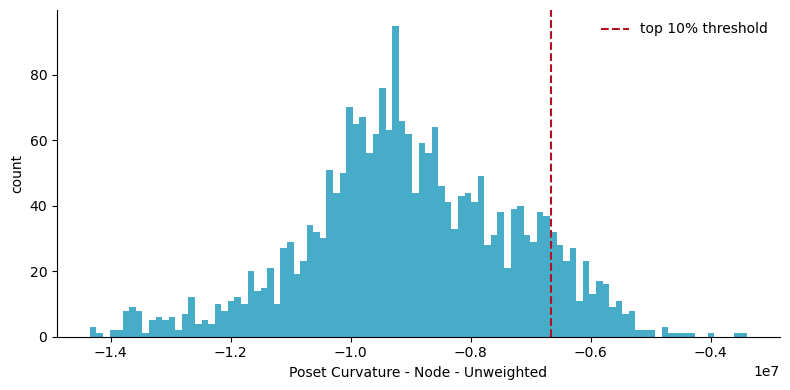

In [31]:
import matplotlib.pyplot as plt

p25 = CN["scalar_curvature"].quantile(0.90)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(CN["scalar_curvature"], bins=100, color="#46ACC8", edgecolor="none")
ax.axvline(p25, color="#B40F20", linestyle="--", label=f"top 10% threshold")
ax.set_xlabel("Poset Curvature - Node - Unweighted")
ax.set_ylabel("count")
#ax.set_title("Distribution of Node Centrality Scores")
ax.legend(frameon=False)
sns.despine(top=True)
plt.tight_layout()
plt.show()

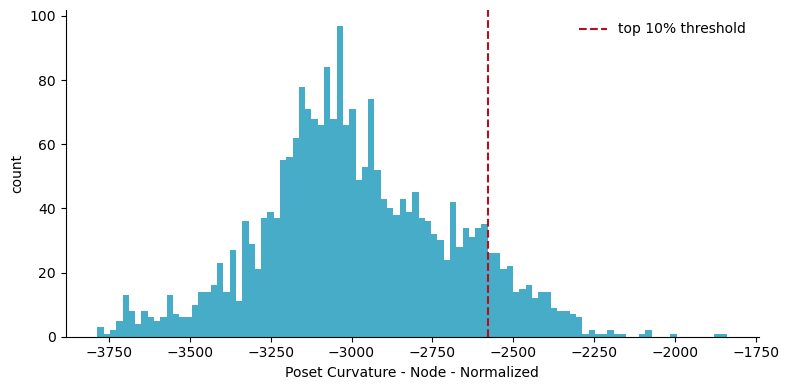

In [32]:
import matplotlib.pyplot as plt

p25 = CN["normalized_scalar_curvature"].quantile(0.90)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(CN["normalized_scalar_curvature"], bins=100, color="#46ACC8", edgecolor="none")
ax.axvline(p25, color="#B40F20", linestyle="--", label=f"top 10% threshold")
ax.set_xlabel("Poset Curvature - Node - Normalized")
ax.set_ylabel("count")
#ax.set_title("Distribution of Node Centrality Scores")
ax.legend(frameon=False)
sns.despine(top=True)
plt.tight_layout()
plt.show()

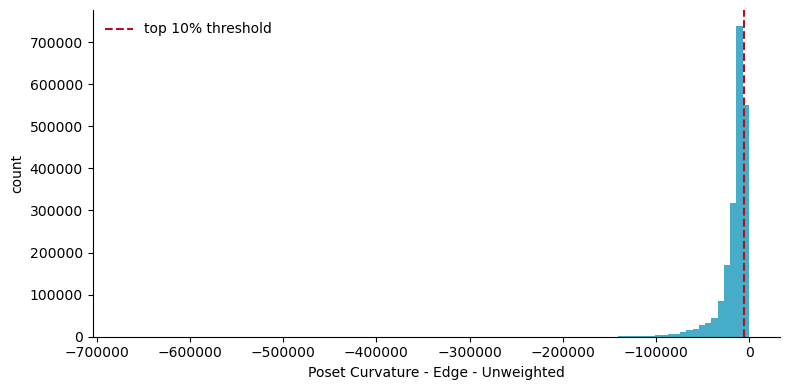

In [33]:
import matplotlib.pyplot as plt

p25 = CE["edge_curvature"].quantile(0.90)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(CE["edge_curvature"], bins=100, color="#46ACC8", edgecolor="none")
ax.axvline(p25, color="#B40F20", linestyle="--", label=f"top 10% threshold")
ax.set_xlabel("Poset Curvature - Edge - Unweighted")
ax.set_ylabel("count")
#ax.set_title("Distribution of Node Centrality Scores")
ax.legend(frameon=False)
sns.despine(top=True)
plt.tight_layout()
plt.show()

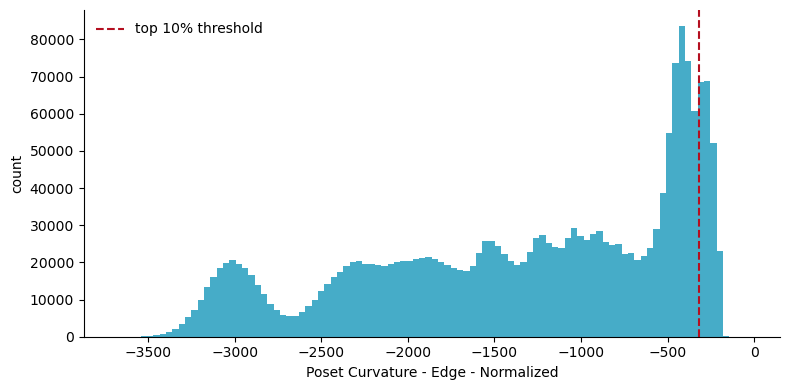

In [34]:
import matplotlib.pyplot as plt

p25 = CE["normalized_edge_curvature"].quantile(0.90)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(CE["normalized_edge_curvature"], bins=100, color="#46ACC8", edgecolor="none")
ax.axvline(p25, color="#B40F20", linestyle="--", label=f"top 10% threshold")
ax.set_xlabel("Poset Curvature - Edge - Normalized")
ax.set_ylabel("count")
#ax.set_title("Distribution of Node Centrality Scores")
ax.legend(frameon=False)
sns.despine(top=True)
plt.tight_layout()
plt.show()